In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
ifg_color = '#6A5ACD'
insula_color = '#D4AF37'


reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')

Using notebook 3d backend.


# Load TRF results

In [29]:
ref = 'bipolar'
task = 'PhonemeSequence'

hga_path = BIDSPath(
    root=f'../results/{task}({ref})',
    datatype='mtrf',
    suffix='m',
    extension='.csv',
    check=False,
)

HGAs = []
for path in tqdm(hga_path.match()):
    df = pd.read_csv(path)
    HGAs.append(df)
    
HGAs = pd.concat(HGAs, ignore_index=True)
HGAs.head()

 10%|█         | 3/30 [00:00<00:02, 13.40it/s]/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1161149/2682651537.py:14: DtypeWarning: Columns (1,2,3,9,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1161149/2682651537.py:14: DtypeWarning: Columns (1,2,3,9,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
 17%|█▋        | 5/30 [00:00<00:03,  6.36it/s]/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1161149/2682651537.py:14: DtypeWarning: Columns (1,2,3,9,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
 20%|██        | 6/30 [00:00<00:03,  6.09it/s]/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1161149/2682651537.py:14: DtypeWarning: Columns (1,2,3,9,12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
 2

,channel,time,weight,pearsonr,feature,subject,task,description,processing,significant,roi,hemi,x,y,z
0,D0019_ROG13-14,-0.203125,0.8480518563328149,0.042281334217962374,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,True,mOccG,R,0.036997543,-0.081192089,-0.0018233725
1,D0019_ROG13-14,-0.1953125,0.8327481169981141,0.042281334217962374,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,True,mOccG,R,0.036997543,-0.081192089,-0.0018233725
2,D0019_ROG13-14,-0.1875,0.5452658214092013,0.042281334217962374,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,True,mOccG,R,0.036997543,-0.081192089,-0.0018233725
3,D0019_ROG13-14,-0.1796875,0.6164798982378298,0.042281334217962374,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,True,mOccG,R,0.036997543,-0.081192089,-0.0018233725
4,D0019_ROG13-14,-0.171875,0.7263921766046976,0.042281334217962374,feature_0,D0019,PhonemeSequence,Repeat,Stimulus,True,mOccG,R,0.036997543,-0.081192089,-0.0018233725


In [30]:
HGAs.roi.unique()

array(['mOccG', 'OPC', 'sOccG', 'Intersection', 'PhG', 'OccS', 'm', 'MFG',
       'SMC', 'SMG', 'IFG', 'STG', 'OFCs', 'CGs', 'SFGs', 'MFGs', 'CG',
       'IFGs', 'Central', 'iOccGs', 'STS', 'INS', 'SFG', 'FuGs', 'Hipp',
       'MTG', 'IPL', 'HG', 'CollatAnt', 'LinGs', 'OFC', 'Sylvian', 'Amyg',
       'VDC', 'FuG', 'LatV', 'PCuns', 'AG', 'SPL', 'TP', 'Put', 'ITG'],
      dtype=object)

In [31]:
coefs = HGAs.groupby('channel').agg({
    'pearsonr': 'first',  
    'significant': 'first',
    'x': 'first',
    'y': 'first', 
    'z': 'first',
    'roi': 'first',
    'hemi': 'first',
    'subject': 'first',
    'description': 'first',
    'task': 'first'
}).reset_index()

coefs = coefs[(coefs.significant==True)]
coefs.head()

,channel,pearsonr,significant,x,y,z,roi,hemi,subject,description,task
12,D0024_LTG12-13,0.046759,True,-0.064921,0.010069,-0.012806,STG,L,D0024,Repeat,PhonemeSequence
13,D0024_LTG14-15,0.526448,True,-0.065791,-0.008037,-0.004994,STG,L,D0024,Repeat,PhonemeSequence
16,D0024_LTG2-3,0.401282,True,-0.055409,0.032218,-0.012219,IFG,L,D0024,Repeat,PhonemeSequence
18,D0024_LTG3-4,0.395705,True,-0.060576,0.023596,-0.008704,SMC,L,D0024,Repeat,PhonemeSequence
19,D0024_LTG4-5,0.452594,True,-0.06326,0.013521,-0.004573,SMC,L,D0024,Repeat,PhonemeSequence


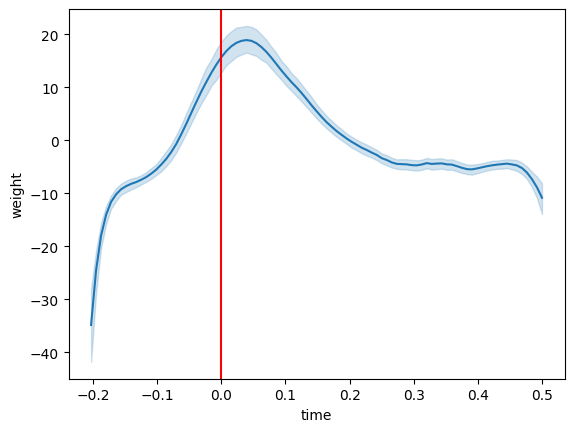

In [35]:
fig, ax = plt.subplots()
sns.lineplot(data=HGAs[
    HGAs.significant==True
    ], 
    x='time', y='weight', ax=ax)

ax.axvline(x=0, color='r')

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/rh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-13 12:27:40.063 ( 162.053s) [    7F954D1BD440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x8e84190): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-13 12:27:40.125 ( 162.116s) [    7F954D1BD440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x137d3310): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: e

左半球: 显示 18 个电极
右半球: 显示 10 个电极


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1161149/3512293968.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


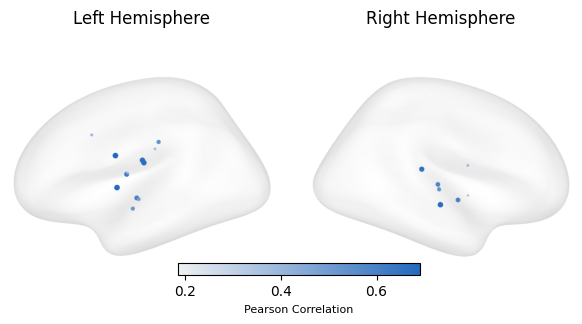

In [ ]:
from IPython.display import display
from PIL import Image
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree
import matplotlib.colors as mcolors

# 读取labels用于显示ROI边界
labels = mne.read_labels_from_annot(
    subject='fsaverage', parc='aparc.a2009s',  
    hemi='both', subjects_dir=recon_dir
)

# 创建Brain对象
lh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)
rh_brain = Brain(
    "fsaverage", subjects_dir=recon_dir, surf="inflated",
    hemi="rh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(600*cm, 600*cm)
)

# 从 coefs 获取数据
cord = coefs[['x', 'y', 'z']].values
hga_values = coefs['pearsonr'].values
hemis = coefs['hemi'].values

# 使用数据中的半球信息
mask_lh = hemis == 'L'
mask_rh = hemis == 'R'


# 设置 colormap 和归一化
cmap = blues
vmin = np.percentile(hga_values, 5)  # 使用5%分位数作为最小值
vmax = np.percentile(hga_values, 95)  # 使用95%分位数作为最大值
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# 点大小映射参数
size_min, size_max = 5, 30

def hga_to_size(hga, vmin, vmax, size_min, size_max):
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)

def hga_to_opacity(hga, vmin, vmax, opacity_min=0.3, opacity_max=1.0):
    """将相关性值映射到透明度"""
    normalized = np.clip((hga - vmin) / (vmax - vmin), 0, 1)
    return opacity_min + normalized * (opacity_max - opacity_min)

def add_electrodes_with_size(brain, coords, hga_vals, cmap, norm, size_min, size_max, use_opacity=False):
    """添加电极到大脑上"""
    for i in range(len(coords)):
        pt = coords[i:i+1]
        hga = hga_vals[i]
        color = cmap(norm(hga))[:3]
        size = hga_to_size(hga, vmin, vmax, size_min, size_max)
        
        # 可选：使用透明度映射
        if use_opacity:
            opacity = hga_to_opacity(hga, vmin, vmax)
        else:
            opacity = 1.0
        
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
            opacity=opacity,
        )

# 加载表面数据用于坐标映射
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

rh_pial_path = f"{recon_dir}/fsaverage/surf/rh.pial"
rh_infl_path = f"{recon_dir}/fsaverage/surf/rh.inflated"
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
rh_coords_infl, _ = mne.read_surface(rh_infl_path)
rh_tree = cKDTree(rh_coords_pial)

# 设置是否使用透明度映射
use_opacity_mapping = False  # 改为 True 来启用透明度映射

# 处理左半球电极
if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_hga = hga_values[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_cord_on_infl = lh_coords_infl[lh_indices]
    
    print(f"左半球: 显示 {len(lh_cord)} 个电极")
    add_electrodes_with_size(lh_brain, lh_cord_on_infl, lh_hga, cmap, norm, size_min, size_max, use_opacity_mapping)

# 处理右半球电极
if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_hga = hga_values[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_cord_on_infl = rh_coords_infl[rh_indices]
    
    print(f"右半球: 显示 {len(rh_cord)} 个电极")
    add_electrodes_with_size(rh_brain, rh_cord_on_infl, rh_hga, cmap, norm, size_min, size_max, use_opacity_mapping)

# 添加所有ROI边界（可选，用于显示解剖区域）
# for lab in labels:
#     if lab.hemi == 'lh':
#         lh_brain.add_label(lab, borders=True, color='gray', alpha=0.3)
#     elif lab.hemi == 'rh':
#         rh_brain.add_label(lab, borders=True, color='gray', alpha=0.3)

for brain in (lh_brain, rh_brain):
    brain.show_view(view="lateral", distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(16*cm, 8*cm))
axes[0].imshow(lh_brain.screenshot(mode="rgb"))
axes[0].axis("off")
axes[0].set_title("Left Hemisphere")

axes[1].imshow(rh_brain.screenshot(mode="rgb"))
axes[1].axis("off")
axes[1].set_title("Right Hemisphere")

# 添加colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', pad=0.1, fraction=0.05)
cbar.set_label('Pearson Correlation', fontsize=8)

lh_brain.close()
rh_brain.close()

plt.tight_layout()
plt.show()